___

# Assignment 3: Introduction to Statistic & Machine learning
___


## Student Information
**Name:** ______Marah Ahmad Aljabali_____  
**Student ID:** _______220210525_______
**Date:** ______9/1/2026___________

## Q1: Dataset Information
What are the dimensions of each MNIST image and how many images are in the training set?

In [2]:
print("MNIST images are 28x28 pixels grayscale images.")
print("The training set contains 60,000 images.")

MNIST images are 28x28 pixels grayscale images.
The training set contains 60,000 images.


## Q2: Load and Verify Data
Load both training and testing datasets. Print their shapes and verify that the training set has 60,000 images and testing set has 10,000 images.

In [3]:
import gzip
import numpy as np
import os

def load_mnist(path, kind='train'):
  """Load MNIST data from `path`"""
  labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
  images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

  with gzip.open(labels_path, 'rb') as lbpath:
    labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

  with gzip.open(images_path, 'rb') as imgpath:
    images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 28, 28)

  return images, labels


mnist_path = './' 

try:
  # Load training and testing data
  train_images, train_labels = load_mnist(mnist_path, kind='train') 
  test_images, test_labels = load_mnist(mnist_path, kind='t10k')

  # Print shapes
  print(f"Training images shape: {train_images.shape}")
  print(f"Training labels shape: {train_labels.shape}")
  print(f"Test images shape: {test_images.shape}")
  print(f"Test labels shape: {test_labels.shape}")

  # Verify the number of images
  if train_images.shape[0] == 60000:
    print("Verification successful: Training set has 60,000 images")
  else:
    print("Verification failed: Incorrect number of images.")

  if test_images.shape[0] == 10000:
    print("Verification successful: Test set has 10,000 images.")
  else:
    print("Verification failed: Incorrect number of images.")

except FileNotFoundError:
  print(f"Error: MNIST files not found in the specified path: '{mnist_path}'")


Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Verification successful: Training set has 60,000 images
Verification successful: Test set has 10,000 images.


## Q3: Visualize Different Digits
Create a 2×5 grid showing one example of each digit (0-9) from the training set.

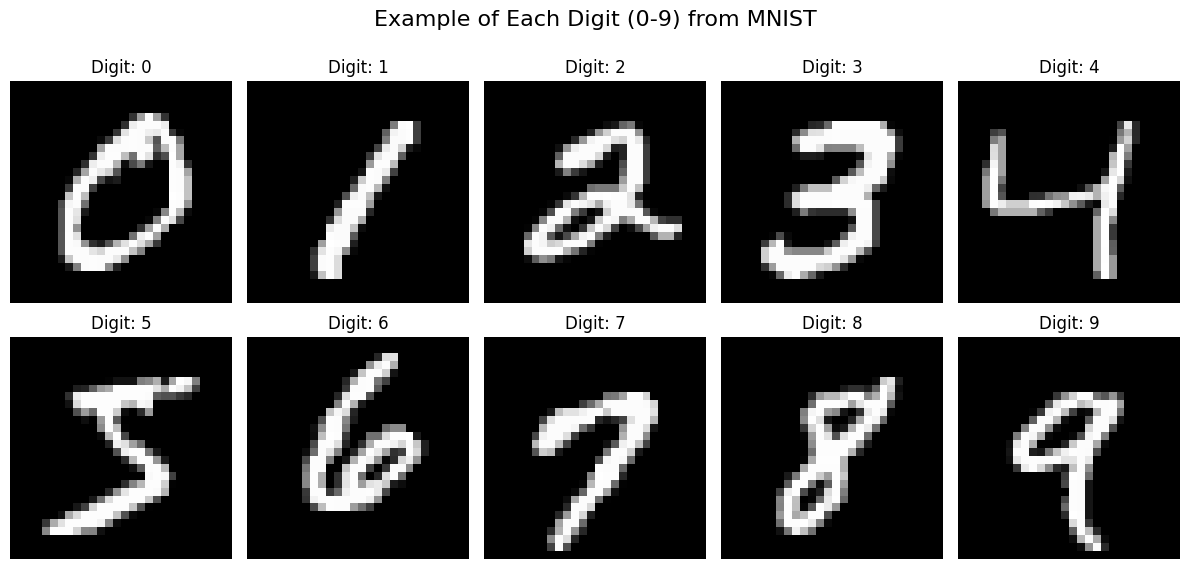

In [4]:
import matplotlib.pyplot as plt

# Create a figure with 2 rows and 5 columns
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Example of Each Digit (0-9) from MNIST", fontsize=16)

# Find one example of each digit
for digit in range(10):
  # Find the first occurrence of the digit
  idx = np.where(train_labels == digit)[0][0]
  
  # Determine the position in the grid
  row = digit // 5
  col = digit % 5
  
  # Display the image
  axes[row, col].imshow(train_images[idx], cmap='gray')
  axes[row, col].set_title(f"Digit: {digit}")
  axes[row, col].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## Q4: Extract and Count Digits
Create a function to extract images of a specific digit. Then count how many images exist for each digit (0-9) in the training set.

Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


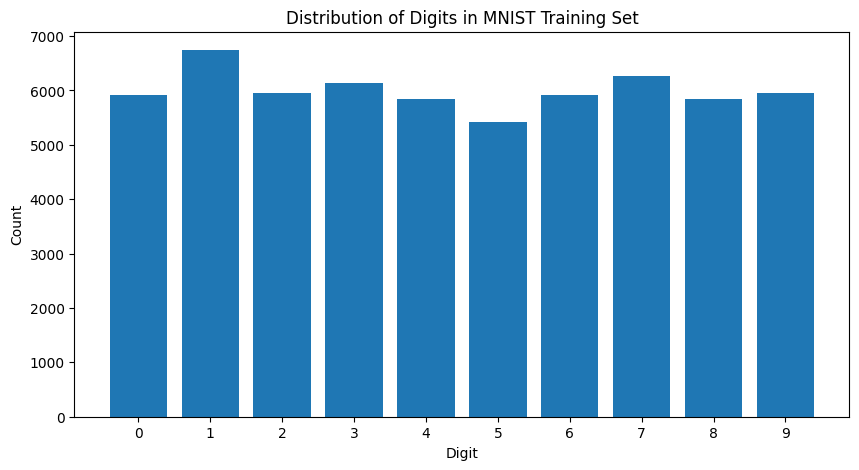

In [5]:
def extract_digit_images(images, labels, digit):
  """Extract all images of a specific digit from the dataset."""
  indices = np.where(labels == digit)[0]
  return images[indices]

# Count how many images exist for each digit
digit_counts = {}
for digit in range(10):
  digit_images = extract_digit_images(train_images, train_labels, digit)
  digit_counts[digit] = len(digit_images)
  print(f"Digit {digit}: {len(digit_images)} images")

# Visualize the distribution
plt.figure(figsize=(10, 5))
plt.bar(digit_counts.keys(), digit_counts.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in MNIST Training Set')
plt.xticks(range(10))
plt.show()

## Q5: Create Digit Montages
Create horizontal montages showing the first 10 images of digits 1, 3, and 7 side by side for comparison.

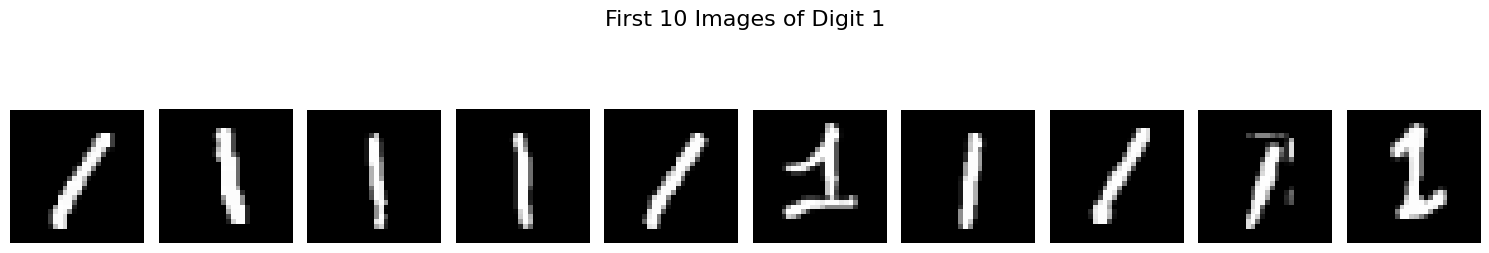

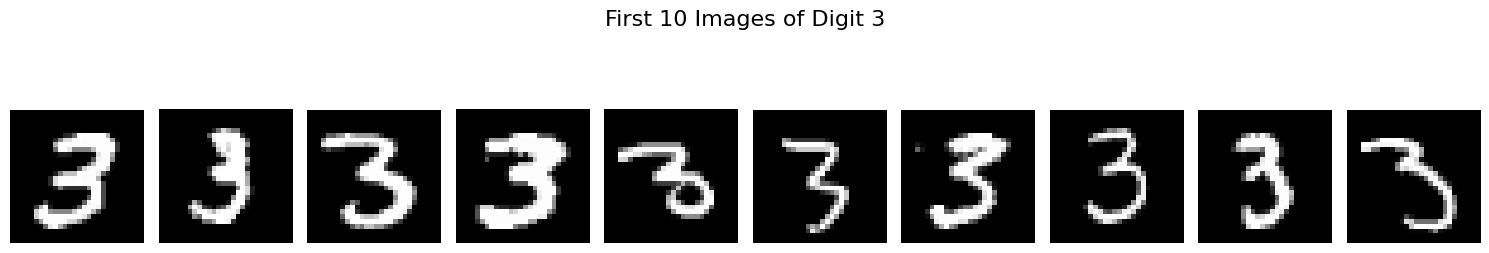

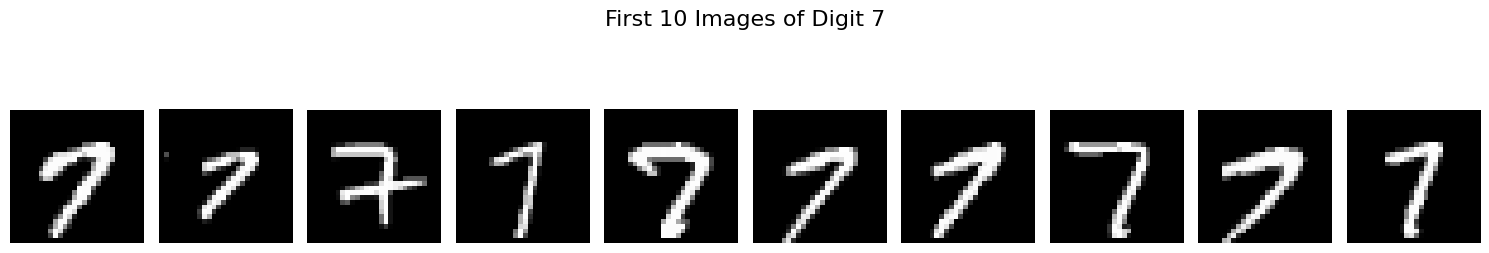

In [11]:
def create_montage(images, title):
  """Create a horizontal montage of images."""
  fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
  fig.suptitle(title, fontsize=16)
  
  # Ensure axes is always iterable
  if len(images) == 1:
    axes = [axes]
      
  for i, img in enumerate(images):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
  
  plt.tight_layout()
  plt.subplots_adjust(top=0.8)
  plt.show()

# Extract the first 10 images of digits 1, 3, and 7
digit_1_images = extract_digit_images(train_images, train_labels, 1)[:10]
digit_3_images = extract_digit_images(train_images, train_labels, 3)[:10]
digit_7_images = extract_digit_images(train_images, train_labels, 7)[:10]

# Create montages
create_montage(digit_1_images, "First 10 Images of Digit 1")
create_montage(digit_3_images, "First 10 Images of Digit 3")
create_montage(digit_7_images, "First 10 Images of Digit 7")

## Q6: Compute Mean and Standard Deviation
For digit 5, compute the mean image and display the digit image and mean image side by side.

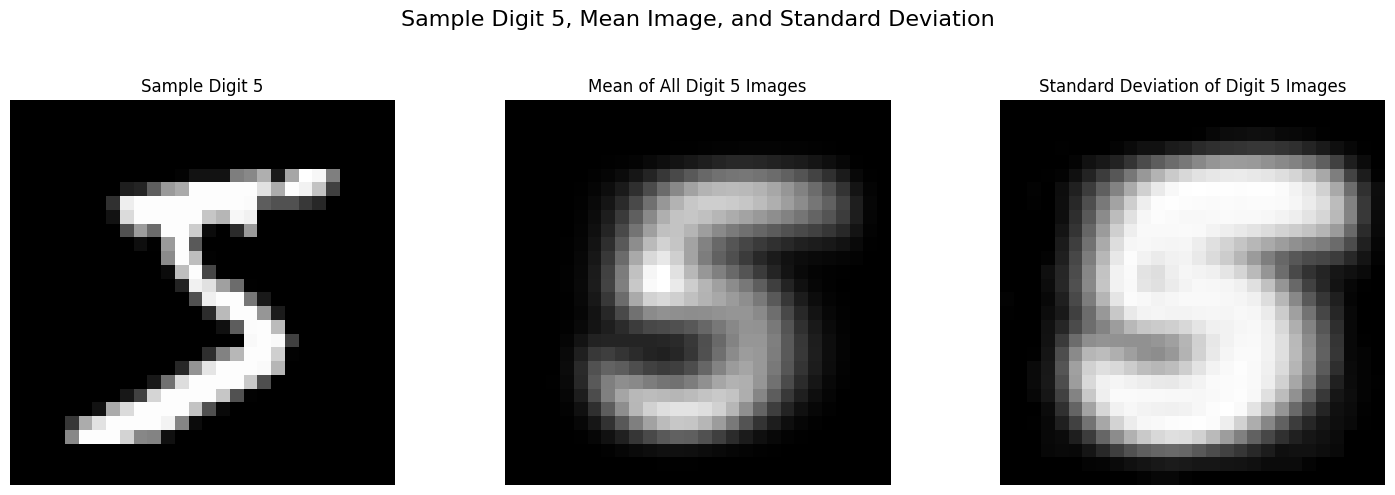

In [12]:
# Extract all images of digit 5
digit_5_images = extract_digit_images(train_images, train_labels, 5)

# Compute the mean image
mean_digit_5 = np.mean(digit_5_images, axis=0)

# Compute the standard deviation image
std_digit_5 = np.std(digit_5_images, axis=0)

# Display a sample digit 5 image and the mean image side by side
sample_idx = 0  # Use the first digit 5 image as a sample

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Sample Digit 5, Mean Image, and Standard Deviation", fontsize=16)

axes[0].imshow(digit_5_images[sample_idx], cmap='gray')
axes[0].set_title("Sample Digit 5")
axes[0].axis('off')

axes[1].imshow(mean_digit_5, cmap='gray')
axes[1].set_title("Mean of All Digit 5 Images")
axes[1].axis('off')

axes[2].imshow(std_digit_5, cmap='gray')
axes[2].set_title("Standard Deviation of Digit 5 Images")
axes[2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()

## Q7: Compare MAE vs MSE Prediction
Create two prediction functions: one using Mean Absolute Error (MAE) and another using Mean Squared Error (MSE). Test both on the first 5 test images and compare results.

In [15]:
# Compute mean images for all digits (0-9) from the TRAINING set
mean_images = {}
for digit in range(10):
  digit_images = extract_digit_images(train_images, train_labels, digit)
  mean_images[digit] = np.mean(digit_images, axis=0)

def predict_using_mae(image, mean_images):
  """Predict the digit using Mean Absolute Error."""
  errors = {}
  for digit, mean_img in mean_images.items():
    # Calculate MAE
    mae = np.mean(np.abs(image - mean_img))
    errors[digit] = mae

  # Return the digit with the minimum error
  return min(errors, key=errors.get)

def predict_using_mse(image, mean_images):
  """Predict the digit using Mean Squared Error."""
  errors = {}
  for digit, mean_img in mean_images.items():
    # Calculate MSE
    mse = np.mean((image - mean_img) ** 2)
    errors[digit] = mse
  
  # Return the digit with the minimum error
  return min(errors, key=errors.get)

# Test both methods on the first 5 test images
print("Testing MAE and MSE prediction on the first 5 test images:")
print("-" * 70)
print("Image # | True Label | MAE Prediction | MSE Prediction | MAE Correct | MSE Correct")
print("-" * 70)

mae_correct = 0
mse_correct = 0

for i in range(5):
  true_label = test_labels[i]
  test_image = test_images[i]
  
  mae_pred = predict_using_mae(test_image, mean_images)
  mse_pred = predict_using_mse(test_image, mean_images)
  
  mae_is_correct = (mae_pred == true_label)
  mse_is_correct = (mse_pred == true_label)
  
  if mae_is_correct:
    mae_correct += 1
  if mse_is_correct:
    mse_correct += 1
  
  print(f"{i+1:7} | {true_label:10} | {mae_pred:14} | {mse_pred:14} | {mae_is_correct:11} | {mse_is_correct:11}")

print("-" * 70)

Testing MAE and MSE prediction on the first 5 test images:
----------------------------------------------------------------------
Image # | True Label | MAE Prediction | MSE Prediction | MAE Correct | MSE Correct
----------------------------------------------------------------------
      1 |          7 |              7 |              7 |           1 |           1
      2 |          2 |              1 |              2 |           0 |           1
      3 |          1 |              1 |              1 |           1 |           1
      4 |          0 |              0 |              0 |           1 |           1
      5 |          4 |              4 |              4 |           1 |           1
----------------------------------------------------------------------


## Q8: Calculate Model Accuracy
Using MSE-based prediction, calculate the accuracy of your model on the entire test set.

In [16]:
# Make predictions for all test images using MSE
predictions = np.array([predict_using_mse(img, mean_images) for img in test_images])

# Calculate accuracy
accuracy = np.mean(predictions == test_labels)

print(f"Model Accuracy on Test Set (using MSE): {accuracy * 100:.2f}%")

Model Accuracy on Test Set (using MSE): 82.03%


## Q9: Find Most Confused Digits
Identify which two digits are most often confused with each other by your model. Show examples of misclassified images.

The most often confused digits are 4 and 9, with 199 misclassifications.

Showing 5 examples of this confusion:


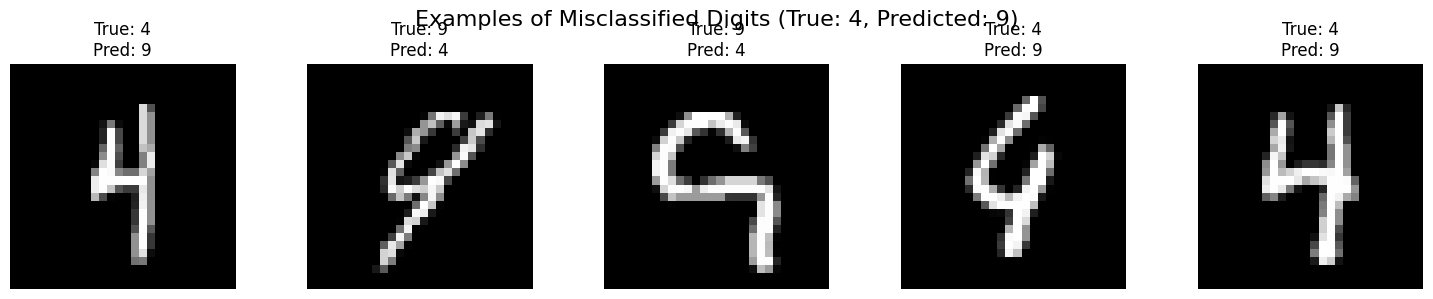

In [17]:
from collections import Counter

# Find all misclassified images
misclassified_indices = np.where(predictions != test_labels)[0]

# Create a confusion matrix for the errors
confusion_pairs = []
for i in misclassified_indices:
  true_label = test_labels[i]
  pred_label = predictions[i]
  # Create a sorted pair to avoid (3,5) and (5,3) being counted separately
  pair = tuple(sorted((true_label, pred_label)))
  if true_label != pred_label: # Ensure it's a misclassification
    confusion_pairs.append(pair)

# Count the frequency of each confused pair
most_common_pair = Counter(confusion_pairs).most_common(1)[0]
digit1, digit2 = most_common_pair[0]
confusion_count = most_common_pair[1]

print(f"The most often confused digits are {digit1} and {digit2}, with {confusion_count} misclassifications.")

# Find examples of this specific confusion
examples_indices = [i for i in misclassified_indices if tuple(sorted((test_labels[i], predictions[i]))) == (digit1, digit2)]

# Show up to 5 examples
num_examples_to_show = min(5, len(examples_indices))
print(f"\nShowing {num_examples_to_show} examples of this confusion:")

fig, axes = plt.subplots(1, num_examples_to_show, figsize=(15, 3))
fig.suptitle(f"Examples of Misclassified Digits (True: {digit1}, Predicted: {digit2})", fontsize=16)

if num_examples_to_show == 1:
  axes = [axes]

for i in range(num_examples_to_show):
  idx = examples_indices[i]
  axes[i].imshow(test_images[idx], cmap='gray')
  axes[i].set_title(f"True: {test_labels[idx]}\nPred: {predictions[idx]}")
  axes[i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()

<center>
    <h4>End of Assignment 3</h4>
</center>